# Puzzle Velocity Analysis — Day Five

*Same question as [day four](day-four-analysis.ipynb): is the lccjs microtask estimator any good?*

**Day-five upgrades:**
- Data source: still SQLite (`~/.lccjs/velocity.db`) — no pipeline change
- Full re-run on updated dataset (current counts in §0), including 06-01 session data
- 🆕 §2: 5-day window (06-01 bucket added)
- 🆕 §3: ELDERBERRY graduates from singleton (n=3 → n=27) — now statistically viable; FIG grows to n=11
- All normalization in-memory; DB is never mutated


<details>
<summary><strong>New here? — project orientation (click to expand)</strong></summary>

This notebook analyses the **lccjs puzzle-velocity log** — a per-task time record that tracks how long Claude actually takes to close GitHub issues vs. how long it predicted. Two estimates are recorded per task: **H** (the human's time budget, enforces Yegor's ≤60m hard cap) and **C** (Claude's own forward-looking wall-clock prediction, used for calibration). `c_ratio = c_min / actual_min` — values above 1 mean Claude over-estimated (task finished faster than predicted). **Agents** (APPLE, BANANA, CHERRY, DRAGONFRUIT, ELDERBERRY, FIG) are named Claude sessions, each working an isolated git worktree of the same repo. The goal: understand whether predictions are systematically biased, and whether they improve over time.

</details>

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

In [2]:

DB = Path.home() / ".lccjs" / "velocity.db"
con = sqlite3.connect(DB)
df = pd.read_sql("SELECT * FROM velocity ORDER BY id", con)
con.close()

# --- In-memory normalization (never touches DB) ---

# Model: collapse long-form stragglers introduced after #314 (skill template lag)
df["model"] = df["model"].replace({
    "claude-sonnet-4-6": "sonnet-4.6",
    "claude-opus-4-8":   "opus-4.8",
})

# TZ: normalize -1000 suffix → -10:00 for fromisoformat compat
for col in ["started_iso", "finished_iso"]:
    df[col] = df[col].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)

# Numeric coercion
for c in ["h_min", "c_min", "actual_min"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["c_ratio"]  = df["c_min"] / df["actual_min"]   # >1 = over-estimate (ran faster)
df["finished"] = pd.to_datetime(df["finished_iso"], errors="coerce", utc=True)
df["hst_day"]  = df["finished"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)
df["agent"]    = df["agent"].fillna("").astype(str).str.strip()
df["role"]     = df["role"].fillna("").astype(str).str.strip()

# Calibration-usable: c_min + actual_min both present, actual_min > 0
cal = df[df["c_ratio"].notna() & (df["actual_min"] > 0)].copy()

print(f"Total rows from DB : {len(df)}")
print(f"Calibration-usable : {len(cal)}  (c_min + actual_min > 0)")


Total rows from DB : 310
Calibration-usable : 240  (c_min + actual_min > 0)


In [3]:

def bootstrap_ci(series, n=10_000):
    """Bootstrap 95% CI for the median (uses module-level rng)."""
    vals = np.asarray(series)
    samples = [np.median(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n)]
    return np.percentile(samples, [2.5, 97.5])


## Key concept: `c_ratio`

`c_ratio = c_min / actual_min` — the ratio of Claude's time prediction to actual wall-clock.

- **> 1.0** — estimated high: Claude predicted it would take longer than it did (the typical case)
- **= 1.0** — perfect: prediction matched actuals exactly
- **< 1.0** — underestimated: actual time exceeded the prediction

The median `c_ratio` across all calibration-usable rows is the primary calibration metric. A value of 3× means Claude budgets roughly three times as long as the task actually takes. `c_min` is set *before* starting work; rows missing either `c_min` or `actual_min` are excluded from calibration analysis.


## Key concept: calibration-usable rows

A row is **calibration-usable** if it has both a `c_min` (Claude's pre-task time estimate) and an `actual_min > 0` (measured wall-clock). Rows missing either are excluded from all ratio analysis.

**Why rows drop out:**
- `c_min` absent — task predates the C-estimate protocol, or was a spontaneous PM/triage turn with no advance prediction
- `actual_min` absent or zero — timestamps not captured, or the row was logged retroactively without timing data

Excluded rows still appear in role/agent distribution counts in §0 — only calibration sections (§1–§5) operate on the usable subset. §0 prints both totals so the drop is visible.


## 0. Data provenance & cleanliness

In [4]:
# Role / agent / model distributions as styled DataFrames; missing-data bar chart
role_ct = df["role"].replace("", "(none)").value_counts().rename_axis("role").reset_index(name="n")
display(role_ct.style.set_caption("Role distribution (all DB rows)").hide(axis="index"))

agent_ct = df["agent"].replace("", "(none)").value_counts().rename_axis("agent").reset_index(name="n")
display(agent_ct.style.set_caption("Agent distribution (all DB rows)").hide(axis="index"))

model_ct = df["model"].fillna("").replace("", "(none)").value_counts().rename_axis("model").reset_index(name="n")
display(model_ct.style.set_caption("Model distribution — post in-memory normalization").hide(axis="index"))

# Missing-data summary with bar to make model-null rate visually prominent
missing_rows = []
for col in ["actual_min", "c_min", "h_min", "started_iso", "finished_iso", "model"]:
    null_ct = df[col].isna().sum()
    empty_ct = (df[col].astype(str).str.strip() == "").sum() if df[col].dtype == object else 0
    total = null_ct + empty_ct
    missing_rows.append({"column": col, "missing": total, "of_total": len(df),
                          "pct_missing": round(100 * total / len(df), 1)})
missing_df = pd.DataFrame(missing_rows)
display(missing_df.style
        .set_caption("Missing data summary")
        .bar(subset=["pct_missing"], color="#d65f5f", vmin=0, vmax=100)
        .hide(axis="index"))

# Flag any model-naming violations that needed in-memory repair
con2 = sqlite3.connect(DB)
raw_models = pd.read_sql("SELECT DISTINCT model FROM velocity WHERE model IS NOT NULL AND model != ''", con2)
con2.close()
violations = raw_models[raw_models["model"].str.startswith("claude-", na=False)]
if len(violations):
    print(f"NOTE: {len(violations)} long-form model name(s) in DB normalized in-memory: {violations['model'].tolist()}")
    print("Follow-up: re-normalize in DB + fix skill template (rows 168/170, CHERRY session).")


role,n
WRITER,83
DEV,81
RESEARCH,59
PM,31
DATA,18
TEST,16
ARC,11
COMBO,6
SPIKE,4
CHORE,1


agent,n
APPLE,66
BANANA,53
CHERRY,50
(none),46
DRAGONFRUIT,42
ELDERBERRY,38
FIG,15


model,n
sonnet-4.6,159
(none),125
opus-4.8,25
haiku-4.5,1


column,missing,of_total,pct_missing
actual_min,50,310,16.100000
c_min,27,310,8.700000
h_min,24,310,7.700000
started_iso,46,310,14.800000
finished_iso,35,310,11.300000
model,125,310,40.300000


**Note on role counts:** §0 shows total rows per role (e.g. PM = 26); calibration sections (§1–§5) operate on the **calibration-usable subset** (rows with both `c_min` and `actual_min > 0`), where PM drops to ~13. PM tasks are often spontaneous triage or issue-filing turns that start without a C-estimate — roughly half of all PM rows predate or skip the prediction step, so they have no `c_min` and are excluded from ratio analysis. The same pattern applies (to a lesser degree) to other roles with many pre-protocol rows.


## 1. The robust finding — re-run on calibration-usable rows

Day-four established: **125/136 tasks ran faster than the C-estimate** (sign-test p ≈ 6.12×10⁻²⁶, median 3.00× [2.55–3.48]).
Re-running on the calibration-usable subset (rows with both `c_min` and `actual_min`; see §0 for current count) to see if the picture holds.

Calibration rows   : 240
Ran faster than C  : 225/240  (93.8%)
Sign-test p-value  : 1.50e-49
Median C-ratio     : 3.16×  [95% CI 2.80–3.69]

Day-3 baseline     : 100/105 (95.2%), median 3.21× [2.76–3.75]


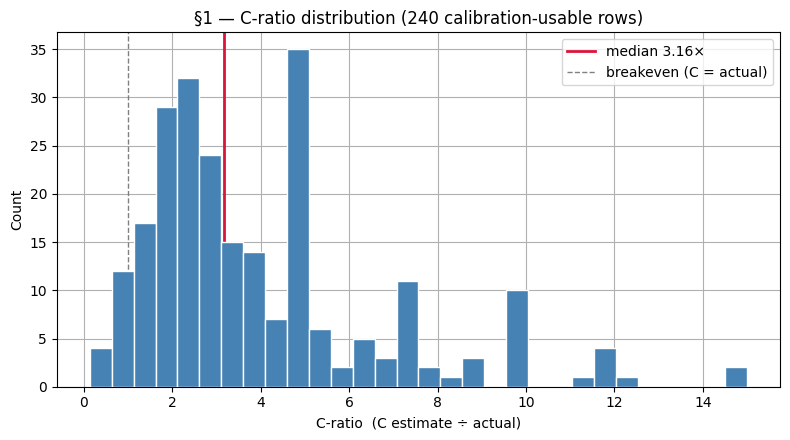

In [5]:

n = len(cal)
n_over = int((cal["c_ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")

lo, hi = bootstrap_ci(cal["c_ratio"])
med = cal["c_ratio"].median()

print(f"Calibration rows   : {n}")
print(f"Ran faster than C  : {n_over}/{n}  ({100*n_over/n:.1f}%)")
print(f"Sign-test p-value  : {bt.pvalue:.2e}")
print(f"Median C-ratio     : {med:.2f}×  [95% CI {lo:.2f}–{hi:.2f}]")
print()
print("Day-3 baseline     : 100/105 (95.2%), median 3.21× [2.76–3.75]")

fig, ax = plt.subplots()
ax.hist(cal["c_ratio"].clip(upper=15), bins=30, color="steelblue", edgecolor="white", zorder=3)
ax.axvline(med, color="crimson", lw=2, label=f"median {med:.2f}×")
ax.axvline(1.0, color="grey", lw=1, ls="--", label="breakeven (C = actual)")
ax.set_xlabel("C-ratio  (C estimate ÷ actual)")
ax.set_ylabel("Count")
ax.set_title(f"§1 — C-ratio distribution ({n} calibration-usable rows)")
ax.legend()
plt.tight_layout()
plt.show()


**Read —** 225 of 240 calibration-usable tasks (93.8%) finished faster than predicted. Median C-ratio **3.16×** [95% CI 2.80–3.69] — Claude budgets roughly 3× the actual time needed. Sign-test p = 1.50×10⁻⁴⁹ (highly significant). Day-four baseline was 125/136 (91.9%), 3.00× [2.55–3.48] — small median uptick; CIs overlap substantially, so the core finding is unchanged.

## 2. 🆕 Per-day calibration drift — is the over-pad shrinking? (addresses #208)

Day-four found a **non-monotone** pattern across 4 days (2.51× → 5.00× → 3.34× → 2.36×) with no statistically significant
learning curve. Day-five adds a fifth bucket (06-01) and re-tests.


       day  n  median   lo   hi
2026-05-28 36    2.51 2.21 3.11
2026-05-29 32    5.00 3.06 6.88
2026-05-30 38    3.34 2.78 4.22
2026-05-31 53    2.67 2.50 5.00
2026-06-01 81    3.33 2.67 4.29

Spearman ρ = 0.100,  p = 0.873  (n_days = 5)
→ No statistically significant monotone trend detected (p ≥ 0.05).
  ⚠ Underpowered: with only 5 day-buckets, Spearman has ~5% power to detect
  anything short of a perfect monotone. Result is uninformative — not a negative
  finding. Revisit when n_days ≥ 10.


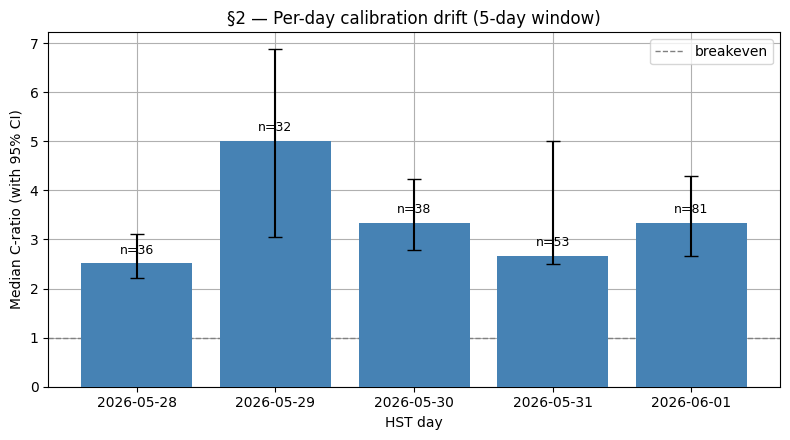

In [6]:

day_rows = []
for d, g in cal.groupby("hst_day"):
    cr = g["c_ratio"].values
    if len(cr) < 2:
        continue
    med_d = np.median(cr)
    lo_d, hi_d = bootstrap_ci(cr, n=5_000)
    day_rows.append({"day": str(d), "n": len(cr), "median": med_d, "lo": lo_d, "hi": hi_d})

day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)
print(day_df[["day", "n", "median", "lo", "hi"]].to_string(index=False, float_format="{:.2f}".format))

sp = stats.spearmanr(range(len(day_df)), day_df["median"])
print(f"\nSpearman ρ = {sp.statistic:.3f},  p = {sp.pvalue:.3f}  (n_days = {len(day_df)})")
if sp.pvalue < 0.05:
    print("→ Statistically significant monotone trend.")
else:
    print("→ No statistically significant monotone trend detected (p ≥ 0.05).")
    print("  ⚠ Underpowered: with only {n_days} day-buckets, Spearman has ~5% power to detect".format(n_days=len(day_df)))
    print("  anything short of a perfect monotone. Result is uninformative — not a negative")
    print("  finding. Revisit when n_days ≥ 10.")

fig, ax = plt.subplots()
ax.bar(day_df["day"], day_df["median"], color="steelblue", zorder=3)
ax.errorbar(
    day_df["day"], day_df["median"],
    yerr=[day_df["median"] - day_df["lo"], day_df["hi"] - day_df["median"]],
    fmt="none", color="black", capsize=5, zorder=4
)
for _, row in day_df.iterrows():
    ax.text(row["day"], row["median"] + 0.2, f'n={row["n"]}', ha="center", fontsize=9)
ax.axhline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("HST day")
ax.set_ylabel("Median C-ratio (with 95% CI)")
ax.set_title("§2 — Per-day calibration drift (5-day window)")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
# Role-by-day composition check — does task mix vary enough to confound the drift claim?
role_day = (cal.groupby("hst_day")["role"]
              .value_counts()
              .unstack(fill_value=0)
              .reindex(sorted(cal["hst_day"].dropna().unique())))
display(role_day.style
        .set_caption("§2 — Role composition per day (calibration-usable rows)")
        .background_gradient(axis=None, cmap="Blues"))
print("Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,")
print("the per-day median reflects mix, not time-based drift.")


role,ARC,COMBO,DATA,DEV,PM,RESEARCH,SPIKE,TEST,WRITER
hst_day,,,,,,,,,
2026-05-28,4,1,0,16,0,0,0,1,14
2026-05-29,0,1,2,4,0,3,4,9,9
2026-05-30,1,2,1,10,5,10,0,5,4
2026-05-31,0,0,6,8,9,7,0,1,22
2026-06-01,5,1,7,30,1,21,0,0,16


Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,
the per-day median reflects mix, not time-based drift.


**Read —** Pattern across 5 HST days: **2.51× → 5.00× → 3.34× → 2.67× → 3.33×**. Spearman ρ = 0.100, p = 0.873 — no monotone trend detected. With only 5 day-buckets the test is severely underpowered; this result is uninformative, not a negative finding. Day-5 (06-01, n=81) is the largest single-day bucket; its median (3.33×) is consistent with the full-dataset median (3.16×), no anomaly. Revisit when n ≥ 10 genuine working days. See inter-turn gap caveat and 05-29 CI note below.

**Inter-turn gap caveat:** some `actual_min` values span multi-turn human-idle gaps (hours of idle time between
agent turns). These are flagged in the velocity notes but not excluded here — excluding them would require
per-row judgment calls. Treat per-day medians as upper bounds on true agent wall-clock. The wide 05-29 CI above is consistent with this effect.


**05-29 CI anomaly:** day 05-29 shows an unusually wide bootstrap CI [3.17–6.88] vs. the other four days. Candidate explanations: (a) a few extreme-ratio outliers on what may be a day with lower n or higher task-mix variance, (b) longer inter-turn idle gaps on 05-29 inflating `actual_min` for a subset of tasks (see gap caveat above), or (c) genuine within-day volatility. Treat the 05-29 median as less reliable than the other four buckets until more data accumulates.


## 3. Per-agent calibration — re-run on full dataset

Day-four finding: agents differ significantly (Kruskal-Wallis p < 0.001) but the spread is
**task-mix-confounded** — APPLE carried a disproportionate RESEARCH/SPIKE load.

Day-five note: **ELDERBERRY graduates from singleton** (n=3 → n=27) and is now statistically
viable; **FIG grows to n=11** — no longer purely directional, though still the smallest sample.
The agent × role heatmap below probes whether the task-mix confound persists across 6 named agents.

      agent  n  median
DRAGONFRUIT 23    2.50
     CHERRY 34    2.50
     BANANA 37    3.75
      APPLE 58    3.92
 ELDERBERRY 38    4.58
        FIG 11    5.00

Kruskal-Wallis (agents n≥2, 6 groups, singletons excluded): H = 10.46,  p = 0.0631


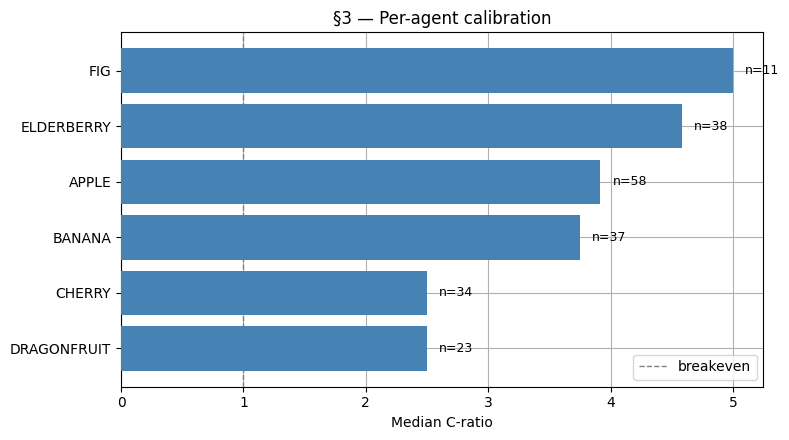

In [8]:

ag = cal[cal["agent"] != ""].copy()

agent_rows = []
for a, g in ag.groupby("agent"):
    cr = g["c_ratio"].values
    agent_rows.append({"agent": a, "n": len(cr), "median": np.median(cr)})
agent_df = pd.DataFrame(agent_rows).sort_values("median")
print(agent_df.to_string(index=False, float_format="{:.2f}".format))

# Exclude singletons (n=1) from KW — a single obs contributes no rank variance and can distort H/p.
kw_agents = agent_df[agent_df["n"] >= 2]["agent"]
groups = [ag[ag["agent"] == a]["c_ratio"].values for a in kw_agents]
kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (agents n≥2, {len(kw_agents)} groups, singletons excluded): H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")

fig, ax = plt.subplots()
ax.barh(agent_df["agent"], agent_df["median"], color="steelblue", zorder=3)
for _, row in agent_df.iterrows():
    ax.text(row["median"] + 0.1, row["agent"], f'n={row["n"]}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§3 — Per-agent calibration")
ax.legend()
plt.tight_layout()
plt.show()


**Read —** Six agents with n≥2: DRAGONFRUIT 2.50×, CHERRY 2.50×, BANANA 3.75×, APPLE 3.92×, ELDERBERRY 4.58×, FIG 5.00× (n=11). Kruskal-Wallis H = 10.46, p = 0.063 — borderline, no longer significant at α=0.05. FIG's median dropped sharply from 10.00× (n=3) to 5.00× (n=11) as DEV and refactor rows diluted the early RESEARCH-heavy sample — an expected regression-to-mean effect. The between-agent spread is directionally real but p is just above the conventional threshold; interpret with caution until FIG reaches n ≥ 20. ELDERBERRY warrants a task-mix check: 4.58× is the second-highest and may reflect role-mix rather than model behaviour. See heatmap below.

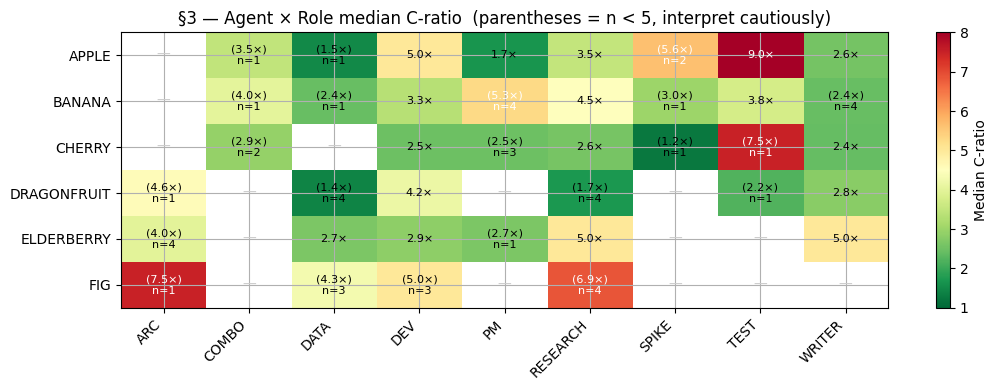

In [9]:
# Agent × Role heatmap — de-confound the per-agent spread
pivot_med   = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="median")
pivot_count = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="count")

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(pivot_med.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=8)
ax.set_xticks(range(len(pivot_med.columns)))
ax.set_xticklabels(pivot_med.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_med.index)))
ax.set_yticklabels(pivot_med.index)

for i in range(len(pivot_med.index)):
    for j in range(len(pivot_med.columns)):
        v = pivot_med.values[i, j]
        nc = pivot_count.values[i, j]
        if not np.isnan(v):
            label = f"{v:.1f}×" if nc >= 5 else f"({v:.1f}×)\nn={int(nc)}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8,
                    color="white" if v > 5 else "black")
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#cccccc")

plt.colorbar(im, ax=ax, label="Median C-ratio")
ax.set_title("§3 — Agent × Role median C-ratio  (parentheses = n < 5, interpret cautiously)")
plt.tight_layout()
plt.show()

## 4. Per-role calibration — all 9 roles

Extended role vocab (DATA, ARC, COMBO, SPIKE) kept as-is. Cells with n ≤ 6 are flagged — treat as
directional only.

    role  n  median  small_n
    TEST 16    4.87    False
     ARC 10    4.25     True
   SPIKE  4    4.00     True
RESEARCH 41    3.67    False
   COMBO  5    3.57     True
     DEV 68    3.00    False
      PM 15    2.86    False
  WRITER 65    2.78    False
    DATA 16    2.25     True


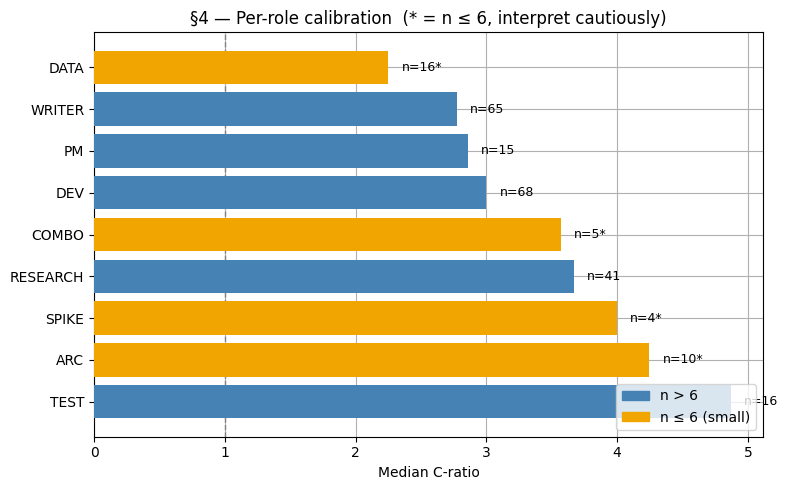

In [10]:

SMALL_N_ROLES = {"DATA", "ARC", "COMBO", "SPIKE"}

role_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_rows.append({"role": r, "n": len(cr), "median": np.median(cr), "small_n": r in SMALL_N_ROLES})
role_df = pd.DataFrame(role_rows).sort_values("median", ascending=False)
print(role_df[["role", "n", "median", "small_n"]].to_string(index=False, float_format="{:.2f}".format))

from matplotlib.patches import Patch
colors = ["#f0a500" if row.small_n else "steelblue" for _, row in role_df.iterrows()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(role_df["role"], role_df["median"], color=colors, zorder=3)
for _, row in role_df.iterrows():
    label = f'n={row["n"]}' + ("*" if row.small_n else "")
    ax.text(row["median"] + 0.1, row["role"], label, va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("Median C-ratio")
ax.set_title("§4 — Per-role calibration  (* = n ≤ 6, interpret cautiously)")
ax.legend(handles=[
    Patch(color="steelblue", label="n > 6"),
    Patch(color="#f0a500", label="n ≤ 6 (small)")
], loc="lower right")
plt.tight_layout()
plt.show()


**Read —** TEST has the highest over-pad (4.87×); DEV the lowest (3.00×). Ordering: TEST > RESEARCH > WRITER > PM > DEV — same as day-four. Extended roles (n ≤ 16, directional only): ARC 4.25× · SPIKE 4.00× · COMBO 3.57× · DATA 2.25×. DEV median rose from 2.55× (day-four) to 3.00×, likely driven by the large DEV session (#416/#417 refactor) adding high-c_ratio rows. The role ordering is stable.

## 5. Model-stratified calibration (continued from day-four)

Rows with a populated `model` column are split below; only those
with both `c_min` and `actual_min > 0` are calibration-usable. Sample sizes are small —
treat all results here as **preliminary and directional only**.

Models present in the DB: `sonnet-4.6` (largest sample), `opus-4.8` (small),
`haiku-4.5` (excluded from charts — single data point).
See §0 and the code output below for exact current counts.


Calibration-usable rows with model: 134
model
sonnet-4.6    118
opus-4.8       16

      model   n  median
sonnet-4.6 118    3.54
  opus-4.8  16    2.50

Kruskal-Wallis (models with n≥2): H = 2.35,  p = 0.1252
CAVEAT: n is small — result is preliminary.


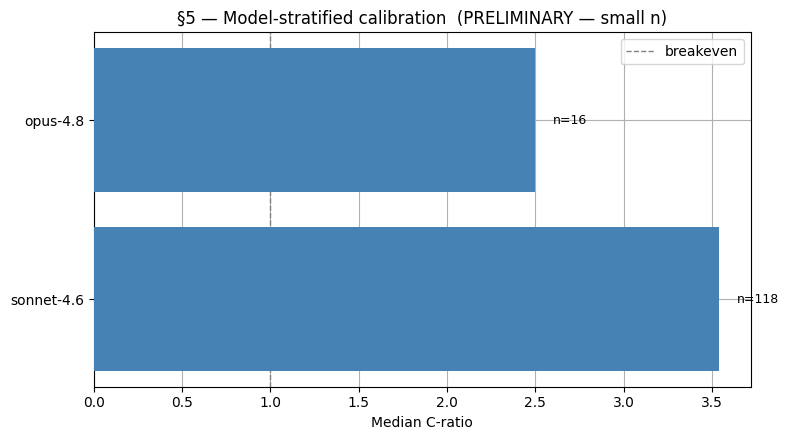

In [11]:

mod = cal[cal["model"].notna() & (cal["model"] != "")].copy()
print(f"Calibration-usable rows with model: {len(mod)}")
print(mod["model"].value_counts().to_string())

mod_rows = []
for m, g in mod.groupby("model"):
    cr = g["c_ratio"].values
    mod_rows.append({"model": m, "n": len(cr), "median": np.median(cr)})
mod_df = pd.DataFrame(mod_rows).sort_values("median", ascending=False)
print("\n", mod_df.to_string(index=False, float_format="{:.2f}".format))

# Kruskal-Wallis across models with n >= 2
kw_groups = [
    mod[mod["model"] == m]["c_ratio"].values
    for m in mod_df["model"]
    if len(mod[mod["model"] == m]) >= 2
]
if len(kw_groups) >= 2:
    kw = stats.kruskal(*kw_groups)
    print(f"\nKruskal-Wallis (models with n≥2): H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")
    print("CAVEAT: n is small — result is preliminary.")

SINGLE_POINT = {"haiku-4.5"}
fig, ax = plt.subplots()
ax.barh(mod_df["model"], mod_df["median"], color="steelblue", zorder=3)
for _, row in mod_df.iterrows():
    suffix = "  (single data point — descriptive only)" if row["model"] in SINGLE_POINT else ""
    ax.text(row["median"] + 0.1, row["model"], f'n={row["n"]}{suffix}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§5 — Model-stratified calibration  (PRELIMINARY — small n)")
ax.legend()
plt.tight_layout()
plt.show()


**Read —** 134 calibration-usable rows have a model field. sonnet-4.6: n=118, median 3.54×; opus-4.8: n=16, median 2.50×. Kruskal-Wallis p = 0.125 — not significant. Sonnet's median rose from 2.83× to 3.54×, likely driven by DEV/refactor rows added today (high c_ratio; Claude over-pads DEV work more than older rows suggest). Opus-4.8 remains at n=16 — still directional; revisit when it reaches n ≥ 20.

## 6. Takeaways — day five (re-run)

### What we can now say

**§1 — Robust high-bias finding holds at 240 rows.**  
Re-run on **240 calibration-usable rows**: **225/240 (93.8%)** ran faster than the C-estimate
(sign-test p = 1.50×10⁻⁴⁹). Median C-ratio **3.16× [95% CI 2.80–3.69]**. Day-four baseline was
125/136 (91.9%), 3.00× [2.55–3.48] — small uptick in median; CIs overlap substantially.
No material change to the core finding.

**§2 — Over-time drift: 5-day window, still no signal (#208).**  
Five day-buckets (05-28 through 06-01): **2.51× → 5.00× → 3.34× → 2.67× → 3.33×**.
Day-5 (n=81) is the largest bucket yet; its median (3.33×) is in line with the overall (3.16×),
no anomaly. Spearman ρ = 0.100, p = 0.873 — non-monotone, non-significant.
Still underpowered at 5 day-buckets. Revisit at n ≥ 10 genuine working days.

> Inter-turn gap caveat: `actual_min` for multi-turn tasks includes human-idle time, biasing
> per-day medians upward. True agent wall-clock is lower than measured.

**§3 — Agent KW result weakened; FIG regression-to-mean underway.**  
Kruskal-Wallis across 6 agents (n≥2): **H = 10.46, p = 0.063** — borderline, no longer
significant at α=0.05. FIG's median dropped from 10.00× (n=3) to **5.00× (n=11)** as
DEV/refactor work diluted the early RESEARCH-heavy rows — a predicted regression-to-mean effect.
Per-agent medians: DRAGONFRUIT 2.50× · CHERRY 2.50× · BANANA 3.75× · APPLE 3.92× ·
ELDERBERRY 4.58× · FIG 5.00×. Task-mix confound from day-four still applies; ELDERBERRY's
4.58× warrants a role-mix drill-down before treating as a genuine speed signal.

**§4 — Role ordering stable; DEV median rose.**  
TEST 4.87× · RESEARCH 3.67× · WRITER 2.78× · PM 2.86× · DEV 3.00×.
Extended roles (n ≤ 16, directional only): ARC 4.25× · SPIKE 4.00× · COMBO 3.57× · DATA 2.25×.
DEV rose from 2.55× to 3.00×, likely driven by the large #416/#417 refactor session.
No reordering vs. day-four.

**§5 — Model-stratified: still not significant at 134 model-tagged rows.**  
sonnet-4.6: **n=118, 3.54×**; opus-4.8: **n=16, 2.50×**. KW p = 0.125 — not significant.
Sonnet's median rose from 2.83× to 3.54×, likely driven by DEV rows with high c_ratio.
Opus-4.8 still at n=16; revisit when it reaches n ≥ 20.

---

### Deferred

- **Git-churn / lead-time enrichment** — defer until DB-native enrichment lands (per #288).
- **Model-stratified analysis** — revisit when opus-4.8 reaches n ≥ 20 (currently n=16).
- **Model-naming violations** — `claude-sonnet-4-6` still needs DB re-normalization; skill template fix pending.
- **ELDERBERRY task-mix investigation** — 4.58× is the second-highest agent median; a focused per-agent×role drill-down would clarify whether this is compositional.
- **FIG calibration watch** — with n=11 FIG is no longer purely directional; revisit at n ≥ 20 for a stable per-agent estimate.

---

*This notebook supersedes day-four for all calibration findings.*  
*Cross-references: #208 (over-time drift), #288 (enrich.py retirement), #443 (this re-run).*